

## Overview

This notebook implements the tactical clustering pipeline for the 2026 World Cup Readiness Framework. Using 8 match-level metrics derived from StatsBomb open data (2022–2024 men's tournaments), we cluster 71 national teams into four tactical archetypes and validate those archetypes against 2022 World Cup outcomes.

All analysis code lives in the `tactical_clustering/` module files:

| File | Purpose |
|---|---|
| `tc_data.py` | Data loading, feature engineering, team-level aggregation |
| `tc_preprocessing.py` | Outlier capping and feature scaling |
| `tc_k_selection.py` | Elbow method and silhouette score sweep |
| `tc_clustering.py` | KMeans fitting, archetype labelling, GMM + sensitivity validation |
| `tc_visualisation.py` | PCA scatter, radar charts, outcome validation plots |
| `tc_outcome_validation.py` | 2022 WC result merging and outcome ranking |

---

## Step 1 — Setup & Data Loading

In [1]:
%config InlineBackend.figure_format = 'retina'

import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Path setup ──────────────────────────────────────────────────────────────
notebook_dir = Path('.').resolve()
project_root = notebook_dir.parent
eda_root     = project_root / 'eda'

sys.path.insert(0, str(notebook_dir))   # tactical_clustering/ modules
sys.path.insert(0, str(eda_root))       # eda/analysis/ data_loader

FIGURES_DIR = notebook_dir / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

# ── Module imports ───────────────────────────────────────────────────────────
from tc_data            import load_pipeline, CORE_METRICS, CLUSTER_FEATURES
from tc_preprocessing   import cap_and_scale
from tc_k_selection     import sweep_k, plot_k_selection
from tc_clustering      import (fit_kmeans_with_scaler, print_centroid_summary,
                                run_gmm_validation, run_sensitivity_check,
                                ARCHETYPE_MAP, ARCHETYPE_COLORS)
from tc_visualisation   import plot_pca_scatter, plot_archetype_radars, plot_outcome_validation
from tc_outcome_validation import merge_outcomes, compute_outcome_summary

print('All imports OK')
print(f'Figures dir: {FIGURES_DIR}')

All imports OK
Figures dir: /Users/yoomioh/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/2026 Spring/Capstone/soccer-analytics-capstone-XOh/tactical_clustering/figures


### 1.1 Load & Aggregate

We load all 8 metric files from the `men_tourn_2022_24` tournament bundle, merge them on `match_id + team`, derive `progressive_carry_pct`, and collapse to one row per team.

Two volatility features are added at aggregation time:
- **`ppda_std`** — match-to-match variance in pressing intensity
- **`possession_pct_std`** — match-to-match variance in possession

These distinguish *High-Variance Elites* (Argentina, Germany) from *High-Variance Reactives* (Japan, Turkey) — teams with similar means but fundamentally different tactical identities.

In [2]:
metrics, team_metrics = load_pipeline()


LOADING: MEN_TOURN_2022_24
  ✓ possession__team__ppda.csv — 398 rows, 71 teams
  ✓ possession__team__field_tilt.csv — 398 rows, 71 teams
  ✓ possession__team__percentage.csv — 398 rows, 71 teams
  ✓ possession__team__value_epr.csv — 398 rows, 71 teams
  ✓ defensive__team__line_height.csv — 398 rows, 71 teams
  ✓ xg__team__totals.csv — 397 rows, 71 teams
  ✓ progression__team__summary.csv — 398 rows, 71 teams
  ✓ advanced__team__xg_buildup.csv — 397 rows, 71 teams

SUCCESS: 8/8 files loaded
Merged shape      : (398, 12)
All metrics found : True

Team-level shape  : (71, 12)
Teams             : 71
=== SHAPE ===
(71, 12)

=== NULL CHECK ===
shape: (1, 12)
┌──────┬──────┬──────────────┬──────────────┬───┬─────────────┬──────────┬─────────────┬───────────┐
│ team ┆ ppda ┆ defensive_li ┆ field_tilt_p ┆ … ┆ avg_xg_per_ ┆ ppda_std ┆ possession_ ┆ n_matches │
│ ---  ┆ ---  ┆ ne_height    ┆ ct           ┆   ┆ buildup_pos ┆ ---      ┆ pct_std     ┆ ---       │
│ u32  ┆ u32  ┆ ---          ┆ --- 

**Audit findings:**
- **No nulls, no duplicates** — 71 teams, all with 3+ matches
- **No low-match teams** — minimum is 3 matches (Copa América group stage)
- **3-sigma outliers flagged:** Georgia (PPDA 31.53), Slovenia (PPDA 23.08), Bolivia/Tanzania (EPR) — these are addressed in preprocessing
- **Benchmarks validated:** PPDA median ~10.06, Possession ~48.4%, Field Tilt ~23.2% — consistent with EDA findings

---
## Step 2 — Preprocessing: Capping & Scaling

### Why cap before scaling?

K-Means minimises distance. Extreme outliers in a feature dominate distance calculations, pulling cluster boundaries toward them and away from the meaningful variation in the rest of the data.

- **PPDA** — Georgia (31.53) and Slovenia (23.08) sat 4+ standard deviations from the median. In initial runs, they formed their own 2-team cluster, a taxonomically meaningless result.
- **EPR** — A 99th percentile cap still produced a cluster centroid at EPR=226. The 95th percentile corrects this.

Capping at 95th percentile preserves the *directional signal* with Georgia still being the most passive team while preventing their *degree* of extremity from dominating cluster geometry.

**Order: cap → scale.** If we scaled first, the outlier would inflate the std used by StandardScaler, compressing all other teams together and making real tactical differences harder to detect.

In [3]:
X, teams, scaler, cap_info = cap_and_scale(team_metrics)

PPDA cap (95%): 22.39  →  3 team(s) affected
EPR  cap (95%): 261.47  →  3 team(s) affected

Feature matrix shape : (71, 10)
Any NaNs             : False

Post-scaling means (should be ~0):
ppda                             0.0
defensive_line_height           -0.0
field_tilt_pct                  -0.0
possession_pct                   0.0
progressive_carry_pct           -0.0
epr                             -0.0
npxg                            -0.0
avg_xg_per_buildup_possession    0.0
ppda_std                         0.0
possession_pct_std              -0.0

Post-scaling stds (should be ~1):
ppda                             1.007
defensive_line_height            1.007
field_tilt_pct                   1.007
possession_pct                   1.007
progressive_carry_pct            1.007
epr                              1.007
npxg                             1.007
avg_xg_per_buildup_possession    1.007
ppda_std                         1.007
possession_pct_std               1.007


---
## Step 3 — K Selection

### 3.1 Elbow Method & Silhouette Sweep

We evaluate k=2 through k=9 using two complementary diagnostics.

k=2 | Inertia: 517.9 | Silhouette: 0.301
k=3 | Inertia: 445.6 | Silhouette: 0.171
k=4 | Inertia: 394.0 | Silhouette: 0.161
k=5 | Inertia: 349.7 | Silhouette: 0.171
k=6 | Inertia: 334.3 | Silhouette: 0.123
k=7 | Inertia: 306.5 | Silhouette: 0.138
k=8 | Inertia: 286.1 | Silhouette: 0.137
k=9 | Inertia: 266.2 | Silhouette: 0.139


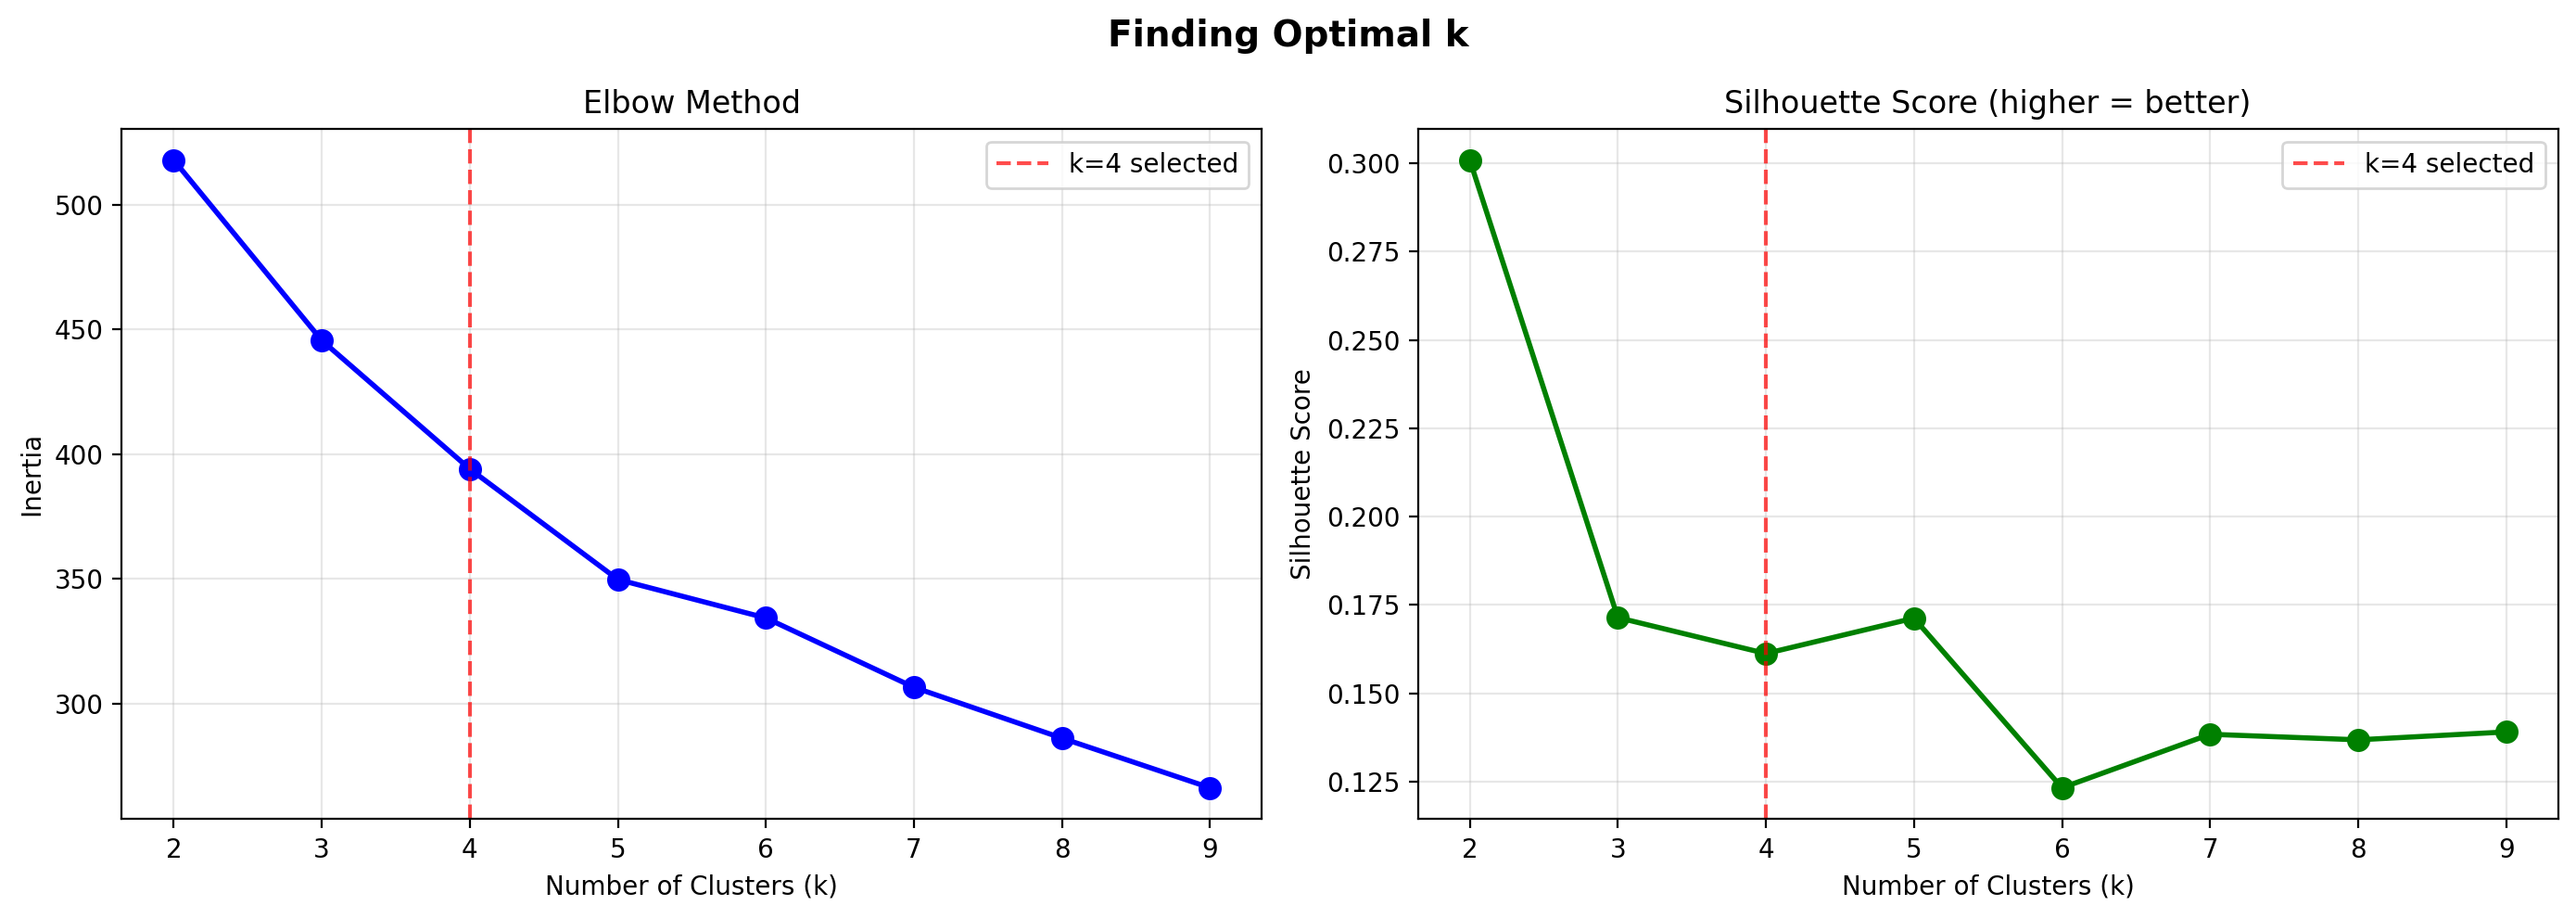

Saved → /Users/yoomioh/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/2026 Spring/Capstone/soccer-analytics-capstone-XOh/tactical_clustering/figures/optimal_k.png


In [4]:
k_range = range(2, 10)
inertias, silhouette_scores = sweep_k(X, k_range)
plot_k_selection(k_range, inertias, silhouette_scores, selected_k=4, figures_dir=FIGURES_DIR)

### 3.2 K Selection Justification: k=4

**Statistical evidence:**  
The inertia curve declines continuously without a pronounced elbow which is consistent with the EDA finding that international teams exist on a tactical continuum rather than in discrete islands. Silhouette scores for k=4 through k=6 are statistically indistinguishable (0.160–0.168), meaning the data provides no quantitative basis for preferring k=5 or k=6. While k=2 yields the highest silhouette (0.309), it produces a trivially binary split, high-press vs low-press, without the resolution required for meaningful 2026 analysis.

**Theoretical grounding:**  
Six independent analytical layers from the EDA phase (metric distributions, correlation structure, tactical scatter plots, quadrant outcome analysis, competition radar profiles, and volatility mapping) consistently identified four distinct tactical profiles:

- **Proactive Dominant:** High press + high possession + high territorial control
- **Possession Adaptive:** Moderate-high possession with lower conversion efficiency
- **Elite Pragmatist (Reactive Disruptors):** Compact defence + transition threat, no possession reliance
- **Passive/Struggling:** Low pressing, low possession, limited tactical identity

**Interpretation of low silhouette scores:**  
Low silhouette values are treated as a substantive finding as they quantitatively confirm that teams do not occupy isolated tactical islands. The four archetypes are **gravitational centres** in tactical space, not hard boundaries. France and Morocco both achieved elite 2022 outcomes from different positions on the tactical continuum, and the clustering framework must preserve that distinction.

---
## Step 4 — K-Means Clustering

### 4.1 Fit & Label Archetypes

In [5]:
kmeans, results, centroid_df = fit_kmeans_with_scaler(X, teams, team_metrics, scaler)
print_centroid_summary(centroid_df)

Cluster distribution:
0    17
1    27
2    19
3     8
Name: cluster, dtype: int64

Cluster centroids (original scale):
          archetype   ppda  possession_pct  defensive_line_height  field_tilt_pct  npxg     epr
Reactive Disruptors 14.327          42.459                  1.327          21.882 0.934  54.471
 Proactive Dominant  8.439          54.050                  1.488          25.989 1.246  49.742
Possession Adaptive  9.426          48.409                  1.436          23.261 0.794  79.984
 Passive Struggling 16.543          41.518                  1.319          15.459 0.400 196.441


### 4.2 Archetype Profiles

| Archetype | n | PPDA | Possession % | Line Height | Field Tilt | npxG | EPR |
|---|---|---|---|---|---|---|---|
| Proactive Dominant | 27 | 8.44 | 54.1% | 1.49 | 26.0% | 1.25 | 49.7 |
| Possession Adaptive | 19 | 9.43 | 48.4% | 1.44 | 23.3% | 0.79 | 80.0 |
| Reactive Disruptors | 17 | 14.33 | 42.5% | 1.33 | 21.9% | 0.93 | 54.5 |
| Passive Struggling | 8 | 16.54 | 41.5% | 1.32 | 15.5% | 0.40 | 196.4 |

**Proactive Dominant (27 teams)**  
The largest cluster and closest match to the EDA "Winner Zone." Aggressive press (PPDA 8.44), possession dominance (54%), high defensive line (1.49), and the highest attacking threat (npxG 1.25). Contains the majority of 2026 title contenders: Argentina, Spain, Germany, France, Brazil, England, Netherlands, Portugal.

**Possession Adaptive (19 teams)**  
With moderate pressing and possession with notably elevated EPR (80.0) these teams have the ball reasonably often but are less efficient at converting control into threat. Key nations: Italy, Serbia, Chile, Ecuador, South Korea. Tactically settled but lacking the attacking output of the Proactive tier.

**Reactive Disruptors (17 teams)**  
Low possession (42.5%) and passive pressing (PPDA 14.33), but a respectable npxG (0.93) relative to ball retention. These teams defend compactly and create through transition. Key nations: Morocco, Japan, Switzerland, Turkey, Poland. Morocco and Japan's placement here directly validates the EDA finding that elite outcomes are achievable without possession dominance.

**Passive Struggling (8 teams)**  
The smallest and weakest cluster. Rarely press (PPDA 16.54), concede territorial control (field tilt 15.5%), minimal attacking threat (npxG 0.40), and highly inefficient with the ball (EPR 196.4). Nations: Bolivia, Qatar, Albania, Scotland, Australia. This represents limited tactical identity rather than a deliberate defensive system.

**EDA validation:**  
France lands in Proactive Dominant (consistent with their high-possession, individual-quality profile) and Morocco lands in Reactive Disruptors (consistent with their defensive compactness and transition identity). Their separation into distinct archetypes, despite both reaching the 2022 WC Final/Semi-Final, validates the framework's ability to distinguish *how* teams achieve results, not just *whether* they do.

---
## Step 5 — Validation

### 5.1 GMM Cross-Validation

In [6]:
agreement, disagreements = run_gmm_validation(X, results)

KMeans silhouette : 0.161
GMM    silhouette : 0.152
Agreement rate    : 69.0%

Disagreements (22 teams):
             team    kmeans_archetype       gmm_archetype      ppda  possession_pct     npxg
          Albania  Passive Struggling Reactive Disruptors 24.406667       35.373333 0.728000
           Angola Reactive Disruptors Possession Adaptive 11.258000       45.814000 1.176400
     Burkina Faso Possession Adaptive  Proactive Dominant  7.495000       48.990000 0.625000
   Czech Republic  Proactive Dominant Possession Adaptive  9.550000       40.396667 1.530000
          Ecuador Possession Adaptive  Proactive Dominant  6.650000       47.055714 0.888429
Equatorial Guinea Reactive Disruptors Possession Adaptive  8.940000       45.600000 0.843750
            Ghana Reactive Disruptors  Proactive Dominant  9.576667       42.623333 0.785000
           Guinea Reactive Disruptors Possession Adaptive 10.206000       49.598000 0.922200
          Hungary Reactive Disruptors Possession Adaptive 

**GMM agreement: 69% (49/71 teams).** The 22 disagreements fall into three patterns:

1. **Genuine boundary teams** — Morocco, Switzerland, Netherlands, Turkey have metric profiles that legitimately place them between two archetypes. Both models are correct, and these teams occupy transitional space between tactical identities.
2. **Low-confidence assignments** — Several African and CONCACAF nations (Angola, Guinea, Jamaica) have only 3–5 matches. Their assignments are indicative rather than definitive.
3. **Internal contradictions** — Czech Republic and Mali show unusual metric combinations (aggressive PPDA paired with low possession) that don't map cleanly onto any archetype.

The silhouette scores are statistically indistinguishable (K-Means: 0.161, GMM: 0.152), confirming neither model reveals a meaningfully superior structure.

### 5.2 Sensitivity Analysis

In [7]:
anchor_df = run_sensitivity_check(X, results)

Anchor team stability across k values:
     team  k3  k4  k5
Argentina   1   1   2
   Brazil   1   1   2
  England   1   1   2
   France   1   1   2
  Germany   1   1   2
    Japan   0   0   3
  Morocco   0   0   3
    Spain   1   1   2


**All 8 anchor teams maintain identical relative groupings across k=3, 4, and 5.** Argentina, Spain, Germany, France, Brazil, and England always cluster together; Japan and Morocco always separate from the possession-dominant elite.

This confirms the core tactical identities are structurally real, and not artifacts of a specific k choice. The consistent separation of Japan and Morocco is particularly significant and it validates the Elite Pragmatist profile as a genuinely distinct tactical identity.

**Conclusion:** k=4 is confirmed. The four archetypes are gravitational centres in tactical space. Teams near cluster centres (Argentina, Spain) have clear identities while teams near edges (Morocco, Netherlands, Switzerland) are genuinely hybrid and will be treated as such in the later section on Readiness Score.

---
## Step 6 — Visualisation

Variance explained — PC1: 40.7%, PC2: 18.9%, Total: 59.7%


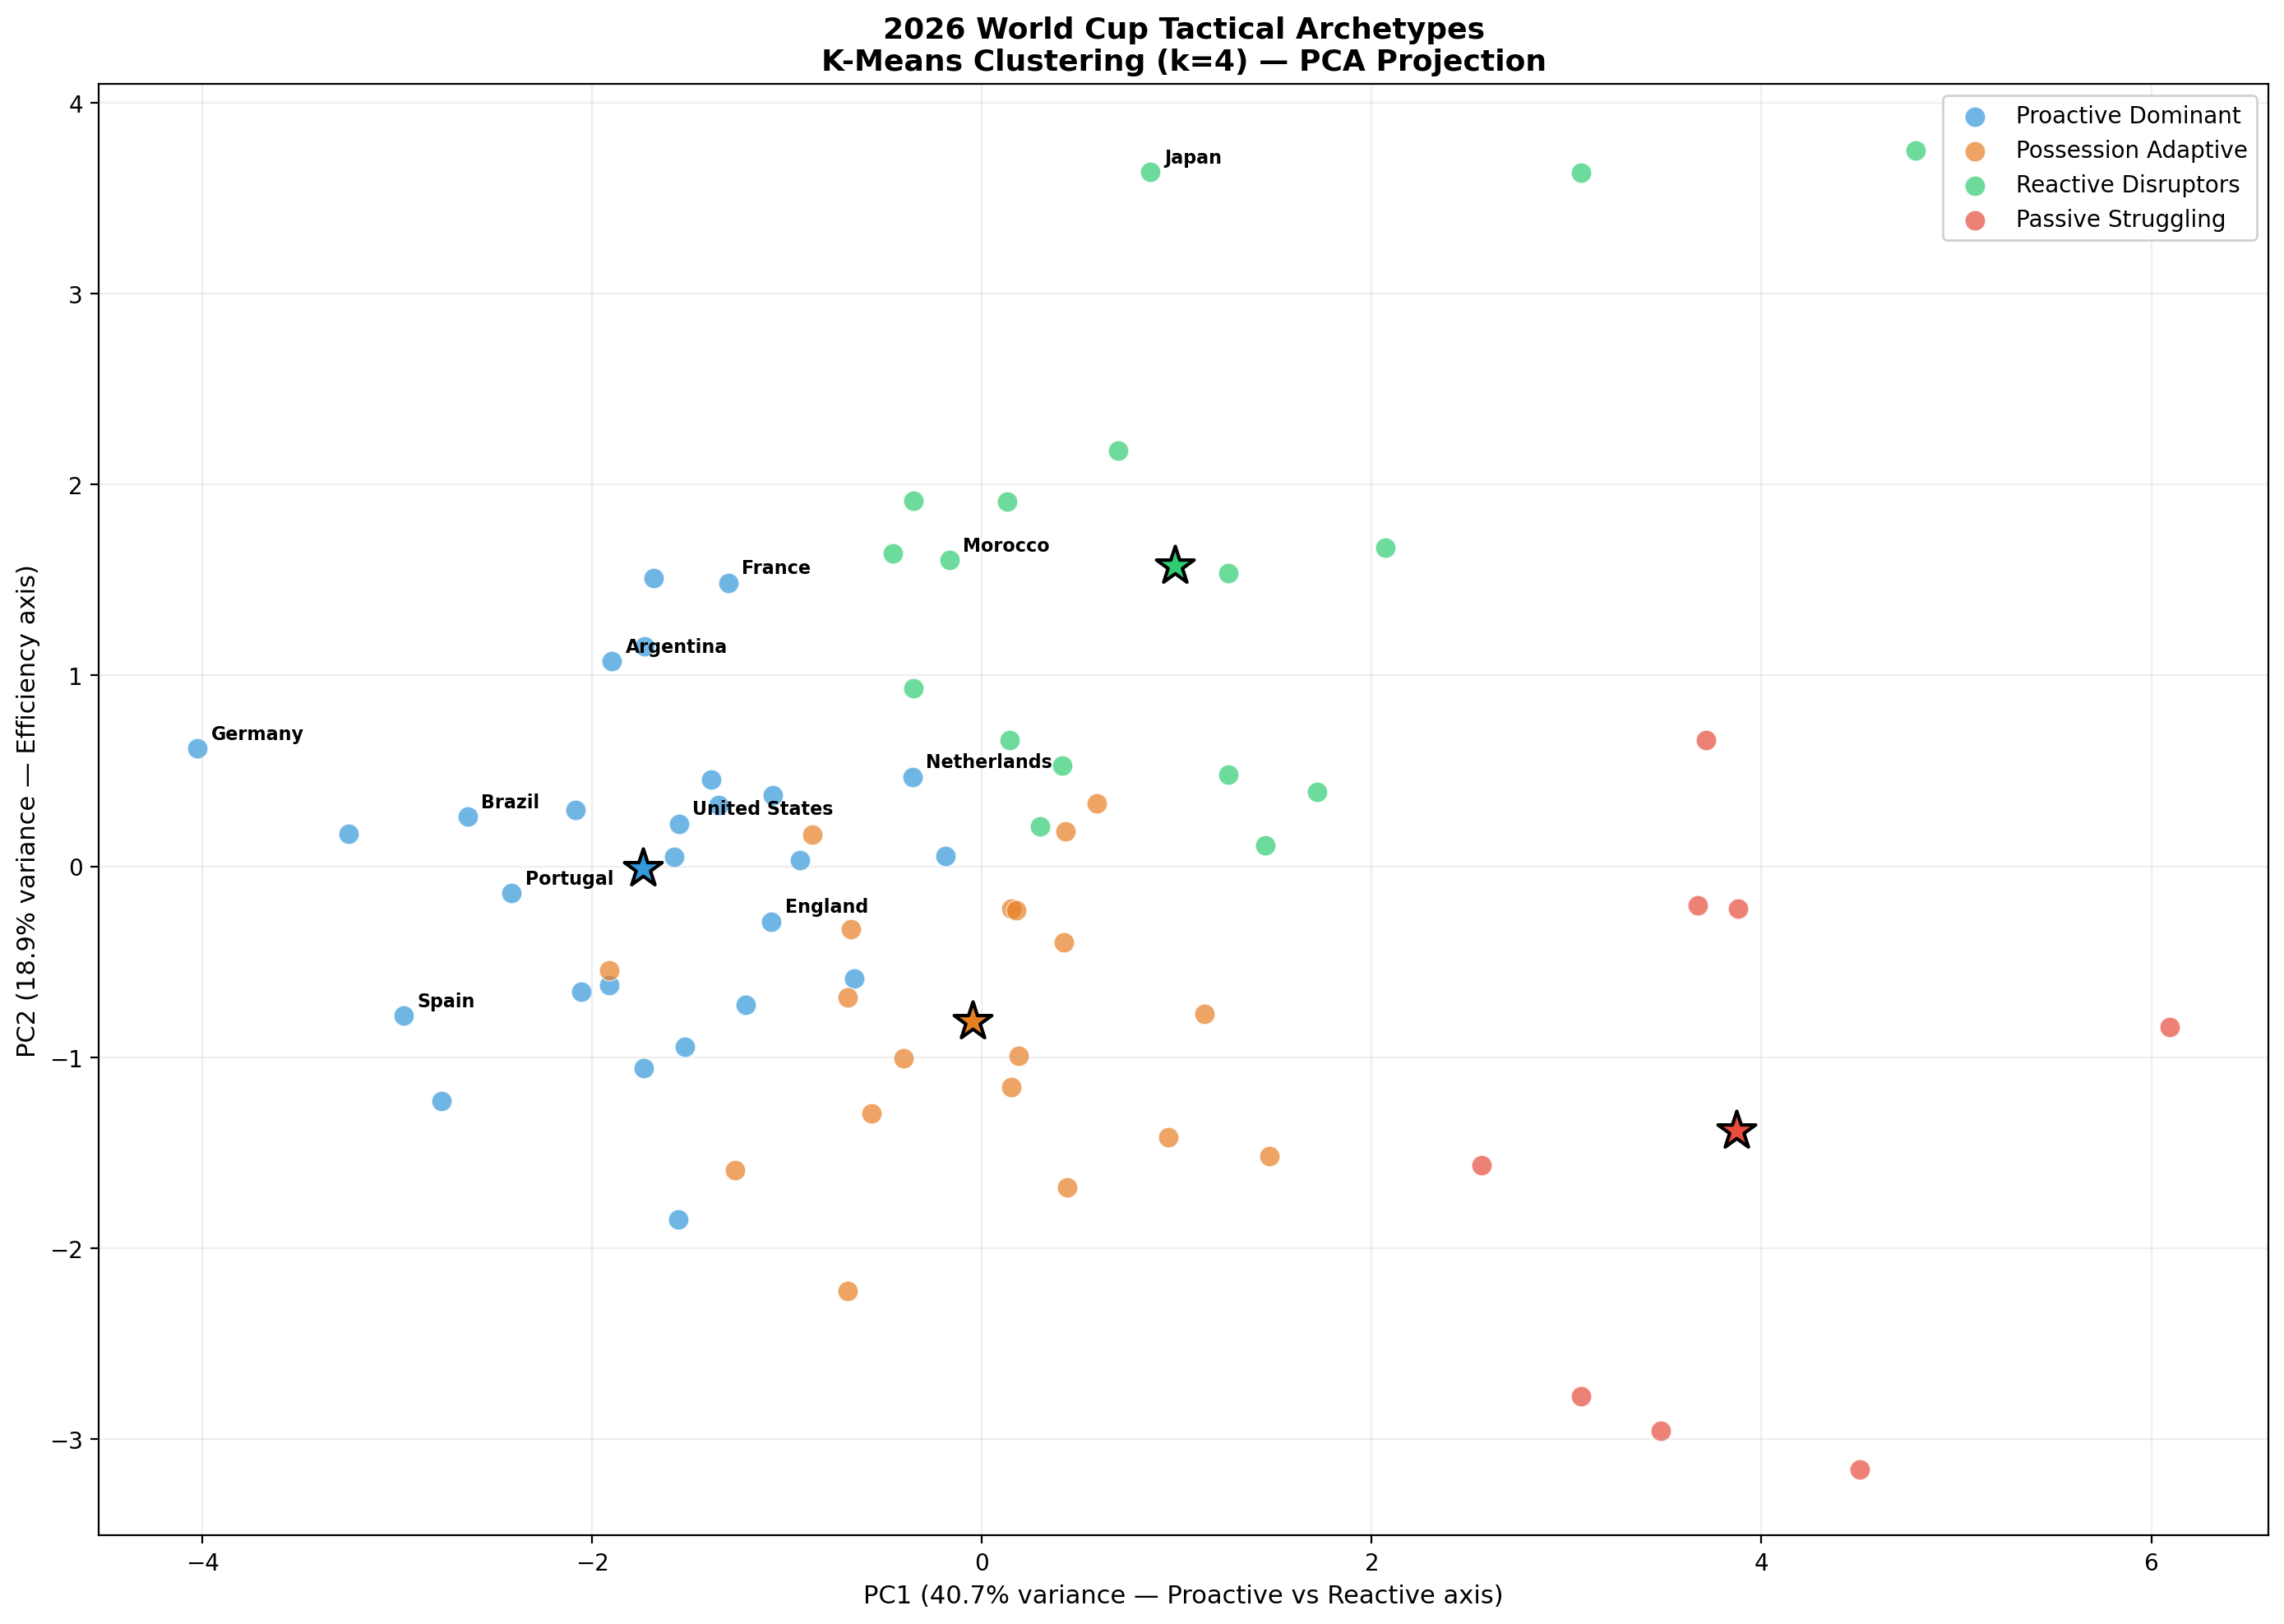

Saved → /Users/yoomioh/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/2026 Spring/Capstone/soccer-analytics-capstone-XOh/tactical_clustering/figures/tactical_clusters_pca.png


In [8]:
results = plot_pca_scatter(X, results, kmeans, figures_dir=FIGURES_DIR)

#### PCA variance: PC1 40.7%, PC2 18.9%, Total 59.7%.

PC1 captures the Proactive vs Reactive axis, Germany and Spain anchor the far left, Passive Struggling teams anchor the far right. PC2 captures the efficiency dimension (EPR). Japan's elevated PC2 position reflects their unusually high possession variance rather than inefficiency which is consistent with the EDA volatility analysis.

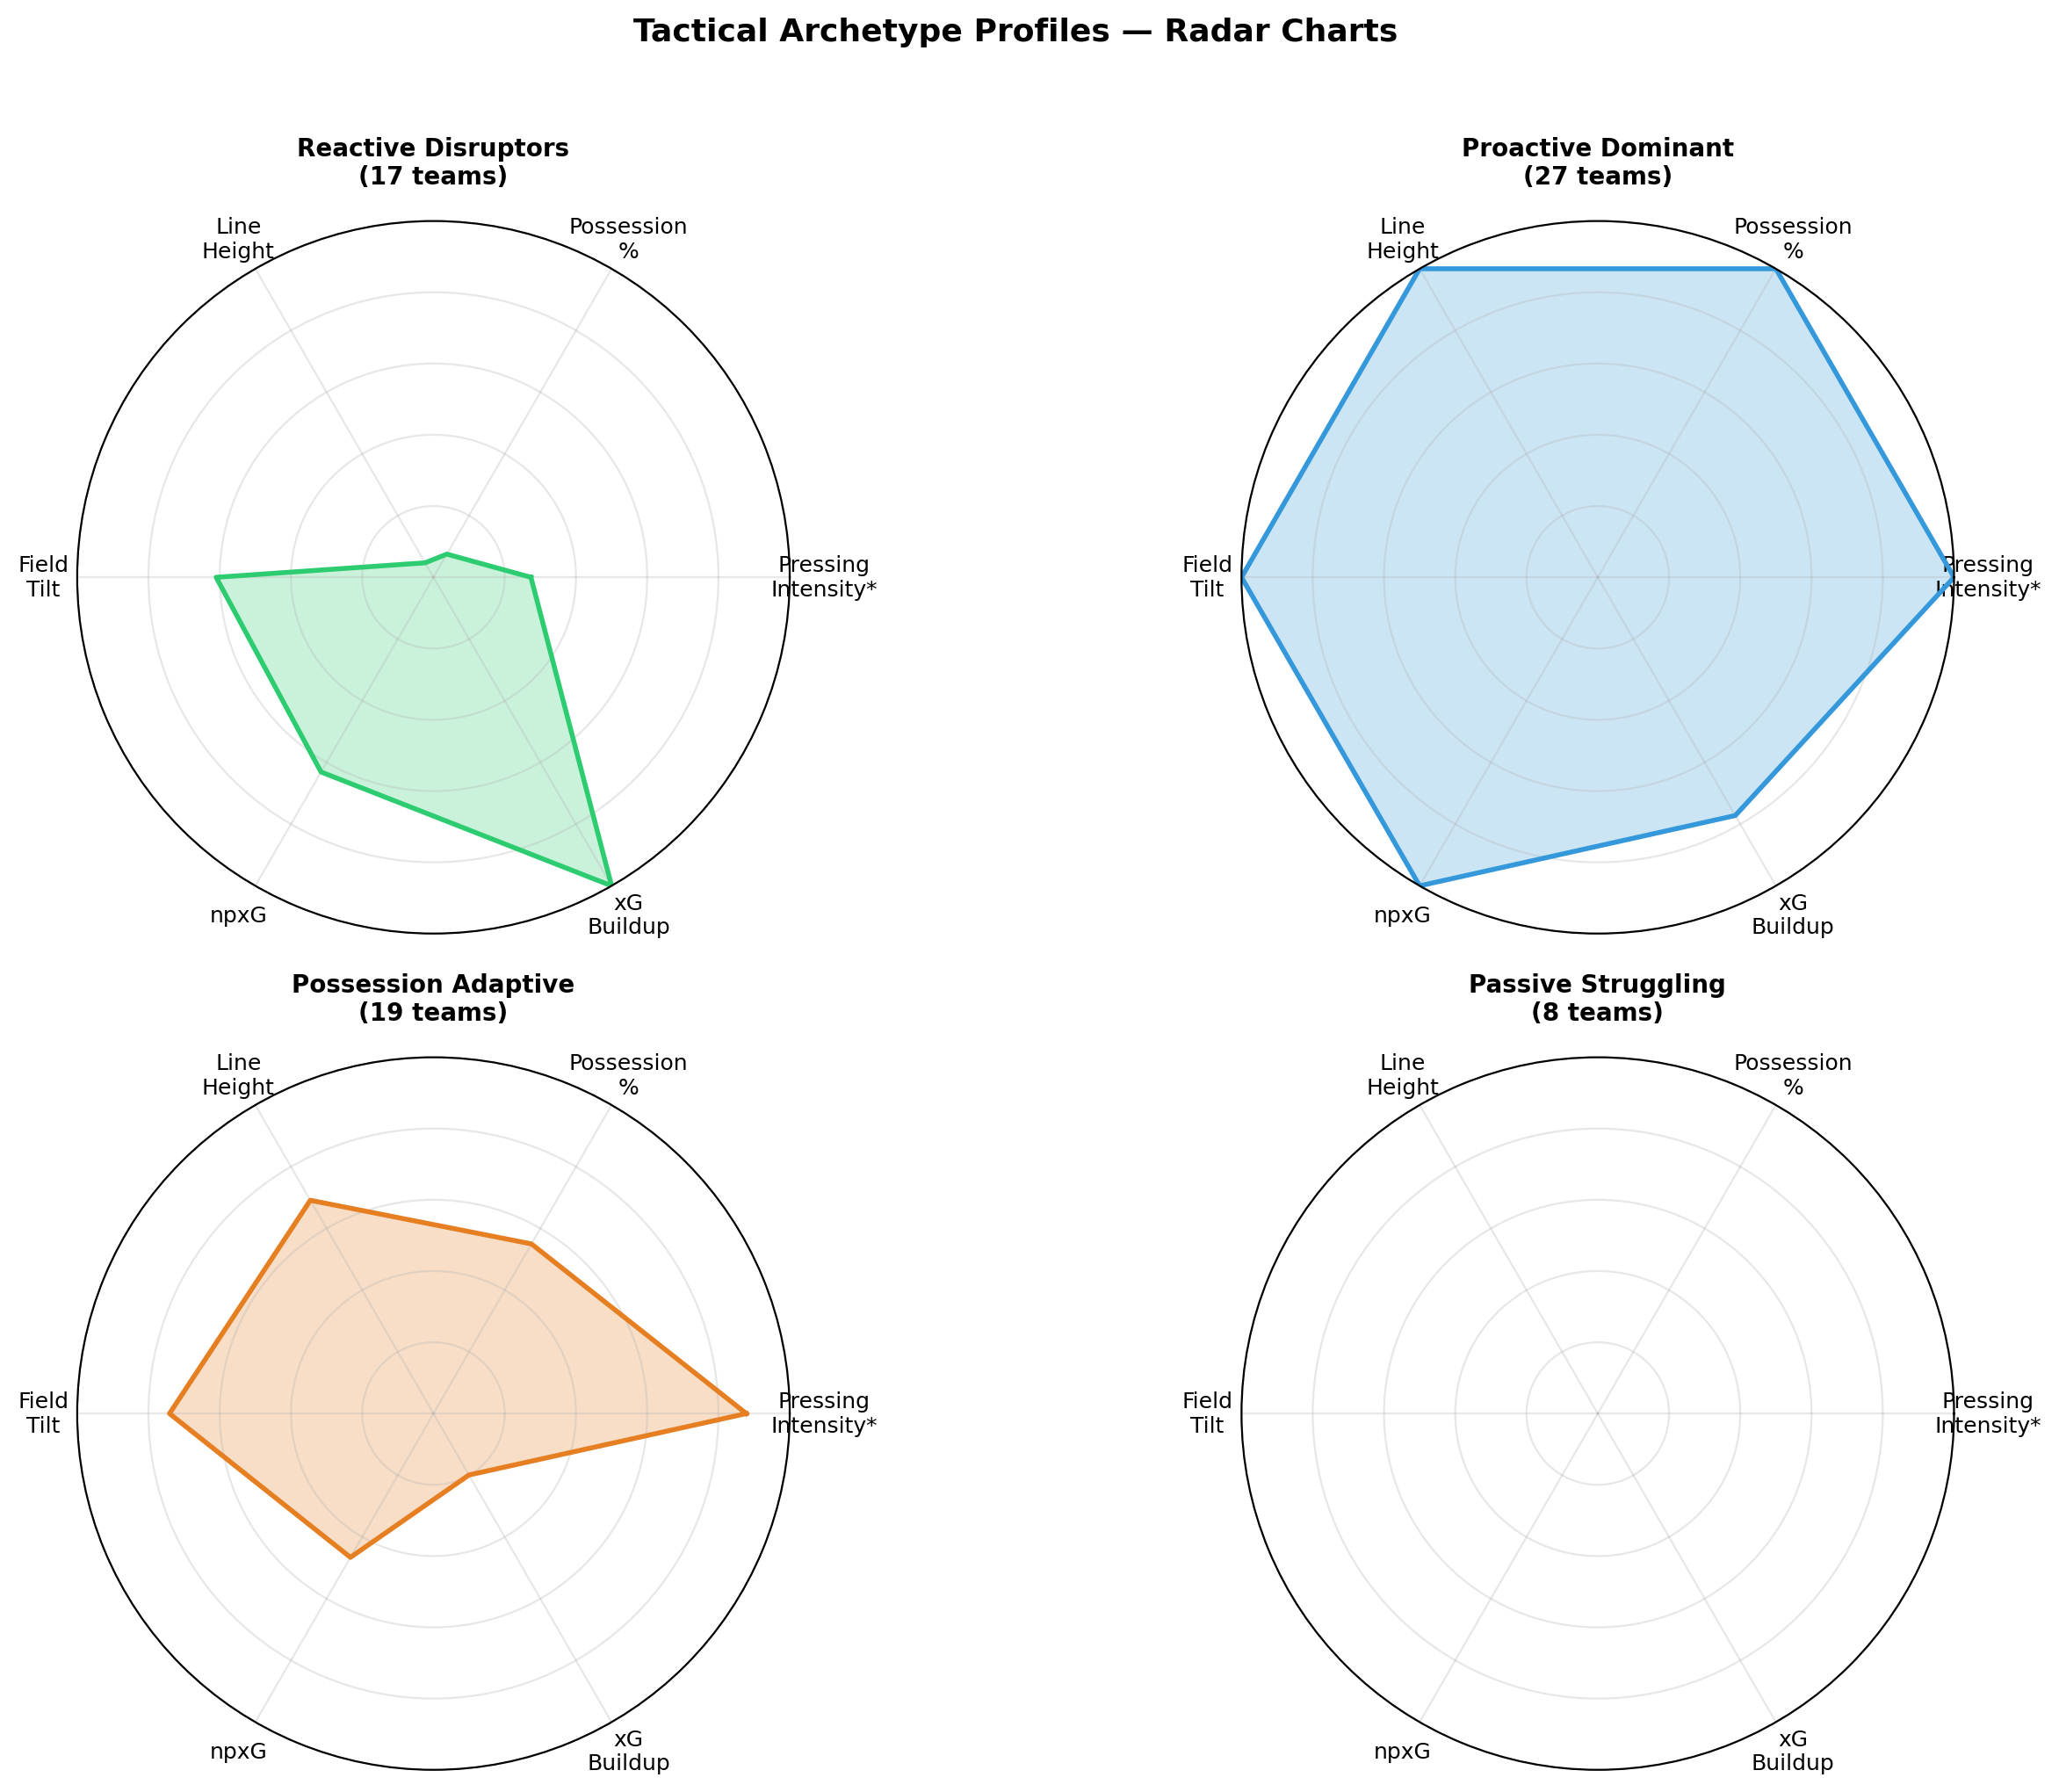

Saved → /Users/yoomioh/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/2026 Spring/Capstone/soccer-analytics-capstone-XOh/tactical_clustering/figures/tactical_archetypes_radar.png


In [9]:
plot_archetype_radars(kmeans, scaler, results, figures_dir=FIGURES_DIR)

Radar shapes confirm archetype differentiation:
- **Proactive Dominant** — large hexagon, strong across all 6 dimensions
- **Reactive Disruptors** — asymmetric, strong on pressing intensity, weak on possession and field tilt
- **Possession Adaptive** — mid-sized, moderate pressing but weak npxG and xG Buildup (sterile possession)
- **Passive Struggling** — minimal shape, weak across all dimensions

---
## Step 7 — Outcome Validation

### Do tactical archetypes predict tournament success?

In [10]:
results, wc_teams = merge_outcomes(results)
wc_teams, avg_rank = compute_outcome_summary(wc_teams, ARCHETYPE_MAP)

WC 2022 teams matched: 32/32

=== Outcome distribution by archetype ===

Reactive Disruptors (6 WC teams):
       team wc2022_outcome
    Morocco         Fourth
      Ghana    Group Stage
       Iran    Group Stage
      Japan    Round of 16
     Poland    Round of 16
Switzerland    Round of 16

Proactive Dominant (16 WC teams):
         team wc2022_outcome
      Belgium    Group Stage
       Canada    Group Stage
      Denmark    Group Stage
      Germany    Group Stage
       Mexico    Group Stage
      Uruguay    Group Stage
       Brazil  Quarter-final
      England  Quarter-final
  Netherlands  Quarter-final
     Portugal  Quarter-final
      Senegal    Round of 16
        Spain    Round of 16
United States    Round of 16
       France      Runner-up
      Croatia          Third
    Argentina         Winner

Possession Adaptive (7 WC teams):
        team wc2022_outcome
    Cameroon    Group Stage
     Ecuador    Group Stage
Saudi Arabia    Group Stage
      Serbia    Group Stage
 

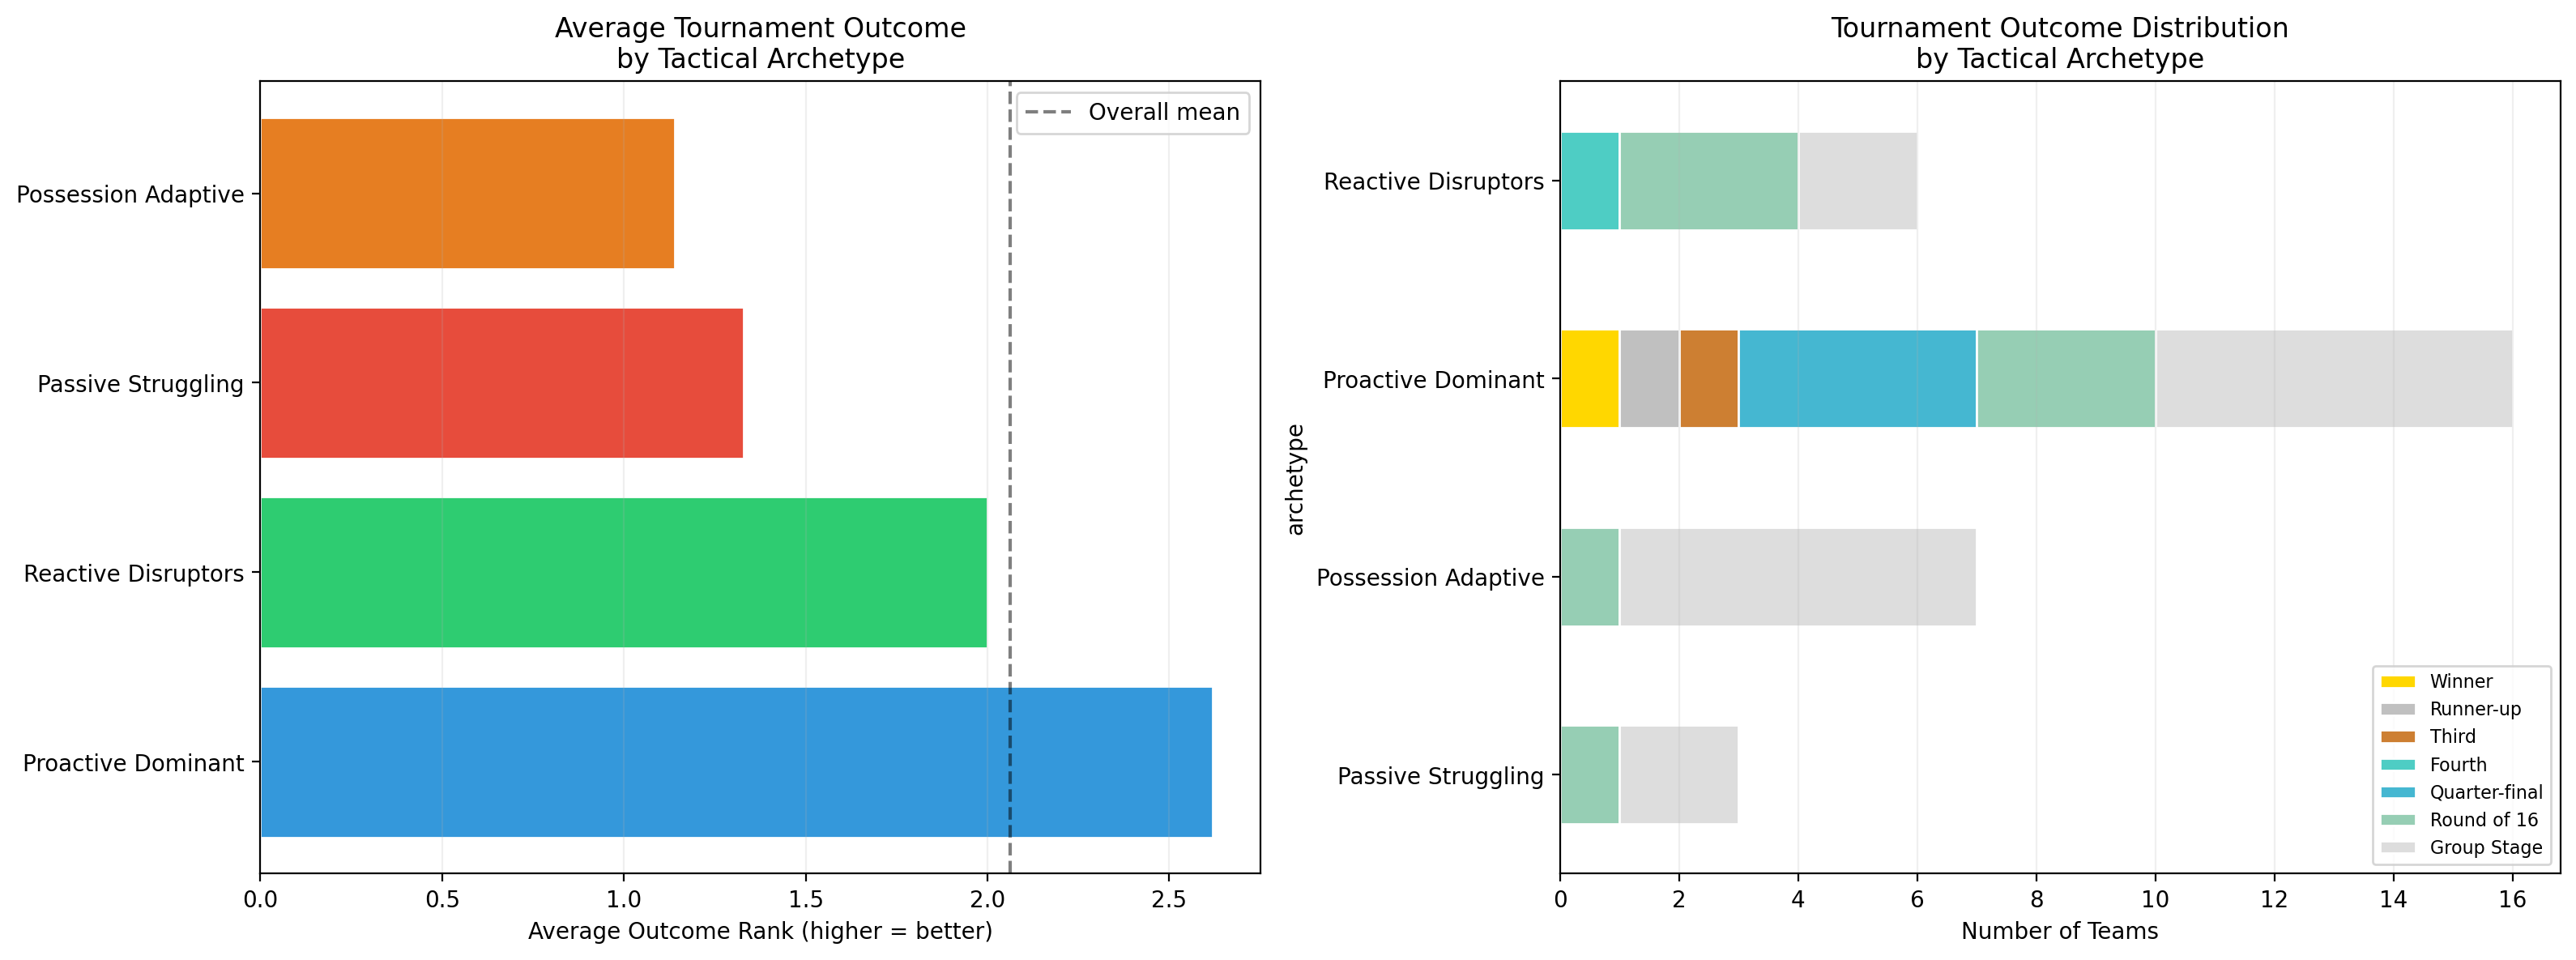

Saved → /Users/yoomioh/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/2026 Spring/Capstone/soccer-analytics-capstone-XOh/tactical_clustering/figures/outcome_validation.png


In [11]:
plot_outcome_validation(wc_teams, avg_rank, figures_dir=FIGURES_DIR)

### 7.1 Findings

| Archetype | WC Teams | Avg Outcome Rank | Best Finish |
|---|---|---|---|
| Proactive Dominant | 16 | **2.62** | Winner |
| Reactive Disruptors | 6 | 2.00 | Fourth |
| Passive Struggling | 3 | 1.33 | Round of 16 |
| Possession Adaptive | 7 | 1.14 | Round of 16 |

**1. Proactive Dominant is the most reliable path.**  
Average rank 2.62, the highest of any archetype. Contains the Winner (Argentina), Runner-up (France), Third (Croatia), and three of four quarter-finalists. The depth of performance across 16 teams is unmatched.

**2. Reactive Disruptors punch above their weight.**  
Average rank 2.00, driven by Morocco (Fourth) and three Round of 16 teams (Japan, Switzerland, Poland). Validates the EDA finding that compact defence + transition threat is a legitimate path to deep tournament runs.

**3. The Possession Adaptive paradox.**  
The most counterintuitive finding: Possession Adaptive teams (avg rank 1.14) finish *lower* than even Passive Struggling teams (1.33). Only South Korea reached the Round of 16; all others exited in the group stage. This directly confirms the EDA "sterile possession" finding — ball control without territorial dominance or attacking threat is a tournament liability, not an asset.

**4. The Passive Struggling floor.**  
Australia's Round of 16 run is the ceiling for this cluster. The combination of low npxG (0.40) and extreme EPR (196) reflects teams that cannot generate or sustain attacking threat regardless of individual quality.

### 7.2 Implications for Readiness Score

The outcome validation produces a clear tactical hierarchy that feeds into the Readiness Score:

1. **Proactive Dominant** : positive archetype multiplier
2. **Reactive Disruptors** : neutral multiplier (ceiling constraints offset transition upside)
3. **Passive Struggling** : moderate penalty
4. **Possession Adaptive** : penalty (sterile possession historically underperforms)

Additionally, the 22 GMM boundary teams will receive a *confidence weight* for readiness score as their archetype assignment is treated as probabilistic rather than categorical, reflecting their genuine position between archetypes.